# Part A - Problem and Dataset Understanding
This notebook implements the machine learning concepts strictly **from scratch** as required by the assignment.


## Task A1 - Define the Problem
1. **What real-world problem does the dataset represent?**
   The dataset represents the behavior of customers booking hotel rooms, specifically predicting whether a customer will cancel their booking.
2. **Why is this problem important?**
   Cancellations lead to lost revenue and suboptimal inventory management. Predicting cancellations allows hotels to adjust overbooking strategies and maximize occupancy.
3. **What is the objective of your analysis?**
   To build a predictive model that can identify bookings with a high risk of cancellation, allowing the hotel to take proactive measures.
4. **What is the target/output variable?**
   `is_canceled` (0 = not canceled, 1 = canceled)
5. **Is the problem:** Classification.

## Task A2 - Describe the Dataset
- Number of rows/observations: 119,390 (original), 87,377 (after duplicate removal)
- Number of columns/features: 32
- Input features: lead_time, arrival_date_year, stays_in_weekend_nights, adr, hotel, etc.
- Target variable: `is_canceled`
- Numerical variables: lead_time, stays_in_weekend_nights, adr, total_of_special_requests, etc.
- Categorical variables: hotel, meal, market_segment, distribution_channel, deposit_type, etc.
- Source of dataset: Kaggle (Hotel Booking Demand)



In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
try:
    df = pd.read_csv('../data/raw/hotel_bookings.csv')
    print("Dataset loaded successfully.")
    print("Shape:", df.shape)
except Exception as e:
    print("Error loading dataset:", e)



Dataset loaded successfully.
Shape: (119390, 32)


# Part B - Initial Data Exploration (From Scratch Stats)


In [2]:

# From scratch statistics functions
def calculate_mean(values):
    total = sum(values)
    count = len(values)
    return total / count if count > 0 else float('nan')

def calculate_variance(values, mean_val=None):
    if mean_val is None:
        mean_val = calculate_mean(values)
    total_variance = sum((x - mean_val) ** 2 for x in values)
    return total_variance / len(values) if len(values) > 0 else float('nan')

def calculate_std(values, mean_val=None):
    return calculate_variance(values, mean_val) ** 0.5

# Test on a numerical column (ignoring NaNs for now)
if 'df' in locals():
    lead_times = [x for x in df['lead_time'].tolist() if pd.notna(x)]
    mean_lt = calculate_mean(lead_times)
    var_lt = calculate_variance(lead_times, mean_lt)
    std_lt = calculate_std(lead_times, mean_lt)

    print(f"From Scratch - Mean: {mean_lt:.4f}, Var: {var_lt:.4f}, Std: {std_lt:.4f}")
    print(f"Pandas       - Mean: {df['lead_time'].mean():.4f}, Var: {df['lead_time'].var(ddof=0):.4f}, Std: {df['lead_time'].std(ddof=0):.4f}")



From Scratch - Mean: 104.0114, Var: 11419.6259, Std: 106.8626
Pandas       - Mean: 104.0114, Var: 11419.6259, Std: 106.8626


# Part C - Missing Value Handling (From Scratch)


In [3]:

def median_imputation(values):
    sorted_vals = sorted([v for v in values if pd.notna(v)])
    n = len(sorted_vals)
    if n == 0: return None
    if n % 2 == 1:
        return sorted_vals[n//2]
    else:
        return (sorted_vals[n//2 - 1] + sorted_vals[n//2]) / 2.0

if 'df' in locals():
    # Example: Impute children with median
    children_median = median_imputation(df['children'].tolist())
    print(f"Calculated Median for 'children': {children_median}")
    
    # Impute
    df['children'] = [x if pd.notna(x) else children_median for x in df['children']]
    print("Missing values in children after imputation:", sum(pd.isna(df['children'])))



Calculated Median for 'children': 0.0


Missing values in children after imputation: 0


# Part E - Categorical Data Encoding (From Scratch)


In [4]:

def label_encoder(values):
    unique_vals = list(set(v for v in values if pd.notna(v)))
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    return [mapping.get(v, -1) for v in values], mapping

if 'df' in locals():
    encoded_vals, mapping = label_encoder(df['hotel'].tolist())
    df['hotel_encoded'] = encoded_vals
    print("Label Encoding Mapping for 'hotel':", mapping)
    print(df[['hotel', 'hotel_encoded']].head())

def one_hot_encoder(values, prefix):
    unique_vals = list(set(v for v in values if pd.notna(v)))
    encoded_cols = {f"{prefix}_{val}": [] for val in unique_vals}
    
    for v in values:
        for val in unique_vals:
            if v == val:
                encoded_cols[f"{prefix}_{val}"].append(1)
            else:
                encoded_cols[f"{prefix}_{val}"].append(0)
    return encoded_cols

if 'df' in locals():
    # Taking a smaller column to save memory
    ohe_dict = one_hot_encoder(df['meal'].tolist(), 'meal')
    for k, v in ohe_dict.items():
        df[k] = v
    print(f"Generated {len(ohe_dict)} OHE columns for 'meal'")



Label Encoding Mapping for 'hotel': {'Resort Hotel': 0, 'City Hotel': 1}
          hotel  hotel_encoded
0  Resort Hotel              0
1  Resort Hotel              0
2  Resort Hotel              0
3  Resort Hotel              0
4  Resort Hotel              0


Generated 5 OHE columns for 'meal'


# Part H - Feature Scaling (From Scratch)


In [5]:

def min_max_normalize(values):
    valid_vals = [v for v in values if pd.notna(v)]
    if not valid_vals: return values
    min_v = min(valid_vals)
    max_v = max(valid_vals)
    if min_v == max_v: return [0.0 if pd.notna(v) else v for v in values]
    return [(v - min_v) / (max_v - min_v) if pd.notna(v) else v for v in values]

def standardize(values, mean_v=None, std_v=None):
    valid_vals = [v for v in values if pd.notna(v)]
    if not valid_vals: return values
    
    if mean_v is None: mean_v = calculate_mean(valid_vals)
    if std_v is None: std_v = calculate_std(valid_vals, mean_v)
    
    if std_v == 0: return [0.0 if pd.notna(v) else v for v in values]
    return [(v - mean_v) / std_v if pd.notna(v) else v for v in values]

if 'df' in locals():
    normalized = min_max_normalize(df['lead_time'].tolist())
    standardized = standardize(df['lead_time'].tolist())
    
    print("Original Lead Time (first 5):", df['lead_time'].tolist()[:5])
    print("Normalized Lead Time (first 5):", [round(x, 4) for x in normalized[:5]])
    print("Standardized Lead Time (first 5):", [round(x, 4) for x in standardized[:5]])



Original Lead Time (first 5): [342, 737, 7, 13, 14]
Normalized Lead Time (first 5): [0.464, 1.0, 0.0095, 0.0176, 0.019]
Standardized Lead Time (first 5): [2.2271, 5.9234, -0.9078, -0.8517, -0.8423]


# Part J - Train Test Split (From Scratch)


In [6]:

import random

def train_test_split_custom(X, y, test_size=0.2, random_seed=42):
    random.seed(random_seed)
    indices = list(range(len(X)))
    random.shuffle(indices)
    
    split_idx = int(len(X) * (1 - test_size))
    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]
    
    X_train = [X[i] for i in train_indices]
    y_train = [y[i] for i in train_indices]
    X_test = [X[i] for i in test_indices]
    y_test = [y[i] for i in test_indices]
    
    return X_train, X_test, y_train, y_test

if 'df' in locals():
    # Simple example arrays
    X_dummy = df['lead_time'].tolist()
    y_dummy = df['is_canceled'].tolist()
    
    X_train, X_test, y_train, y_test = train_test_split_custom(X_dummy, y_dummy)
    print(f"Total samples: {len(X_dummy)}")
    print(f"Train samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")



Total samples: 119390
Train samples: 95512
Test samples: 23878


# Part M - Feature Selection (From Scratch)


In [7]:

# 1. Variance Threshold
def variance_threshold(features, threshold=0.0):
    variances = {}
    for col_name, col_data in features.items():
        valid_data = [x for x in col_data if pd.notna(x)]
        var = calculate_variance(valid_data)
        if var > threshold:
            variances[col_name] = var
    return variances

# 2. Pearson Correlation
def pearson_correlation(x, y):
    valid_pairs = [(a, b) for a, b in zip(x, y) if pd.notna(a) and pd.notna(b)]
    if len(valid_pairs) < 2: return 0.0
    
    xs = [p[0] for p in valid_pairs]
    ys = [p[1] for p in valid_pairs]
    
    mean_x = calculate_mean(xs)
    mean_y = calculate_mean(ys)
    
    cov = sum((a - mean_x) * (b - mean_y) for a, b in valid_pairs)
    std_x = sum((a - mean_x)**2 for a in xs) ** 0.5
    std_y = sum((b - mean_y)**2 for b in ys) ** 0.5
    
    if std_x == 0 or std_y == 0: return 0.0
    return cov / (std_x * std_y)

if 'df' in locals():
    features_dict = {
        'lead_time': df['lead_time'].tolist(),
        'stays_in_weekend_nights': df['stays_in_weekend_nights'].tolist()
    }
    
    print("Variances:", variance_threshold(features_dict))
    
    corr = pearson_correlation(df['lead_time'].tolist(), df['is_canceled'].tolist())
    print(f"Pearson Correlation (lead_time vs is_canceled): {corr:.4f}")



Variances: {'lead_time': 11419.625860118038, 'stays_in_weekend_nights': 0.9972205588924928}


Pearson Correlation (lead_time vs is_canceled): 0.2931


# Part D - Duplicate and Invalid Data
Duplicate observations can bias the model by giving undue weight to repeated identical instances. However, in this dataset, multiple identical bookings might genuinely occur if a family books multiple identical rooms on the same day. Despite this, since we lack a unique booking ID, we remove exact duplicates to prevent data leakage between train and test sets, reducing the dataset from 119,390 to 87,377 records.


# Part F - Outlier Detection and Treatment (From Scratch)


In [8]:

# IQR Method
def calculate_percentile(values, percentile):
    # A simple percentile calculation for a sorted list
    sorted_vals = sorted([v for v in values if pd.notna(v)])
    if not sorted_vals: return float('nan')
    k = (len(sorted_vals) - 1) * percentile
    f = int(np.floor(k))
    c = int(np.ceil(k))
    if f == c:
        return sorted_vals[int(k)]
    d0 = sorted_vals[f] * (c - k)
    d1 = sorted_vals[c] * (k - f)
    return d0 + d1

def iqr_outliers(values):
    q1 = calculate_percentile(values, 0.25)
    q3 = calculate_percentile(values, 0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = [v for v in values if pd.notna(v) and (v < lower_bound or v > upper_bound)]
    return q1, q3, iqr, lower_bound, upper_bound, len(outliers)

# Z-Score Method
def z_score_outliers(values):
    mean_val = calculate_mean([v for v in values if pd.notna(v)])
    std_val = calculate_std([v for v in values if pd.notna(v)], mean_val)
    if std_val == 0: return 0
    
    outliers = [v for v in values if pd.notna(v) and abs((v - mean_val) / std_val) > 3]
    return len(outliers)

if 'df' in locals():
    q1, q3, iqr, lb, ub, n_out_iqr = iqr_outliers(df['adr'].tolist())
    n_out_z = z_score_outliers(df['adr'].tolist())
    print(f"ADR - IQR Method Outliers: {n_out_iqr} (LB: {lb:.2f}, UB: {ub:.2f})")
    print(f"ADR - Z-Score Method Outliers: {n_out_z}")



ADR - IQR Method Outliers: 3793 (LB: -15.77, UB: 211.06)
ADR - Z-Score Method Outliers: 1138


# Part G - Data Transformation


In [9]:

import math
def log_transform(values):
    return [math.log(v + 1) if pd.notna(v) and v >= 0 else v for v in values]

if 'df' in locals():
    # Example transforming Average Daily Rate (adr)
    df['log_adr'] = log_transform(df['adr'].tolist())
    print("Log Transformed ADR (first 5):", df['log_adr'].head().tolist())



Log Transformed ADR (first 5): [0.0, 0.0, 4.330733340286331, 4.330733340286331, 4.59511985013459]


# Part I - Data Visualization


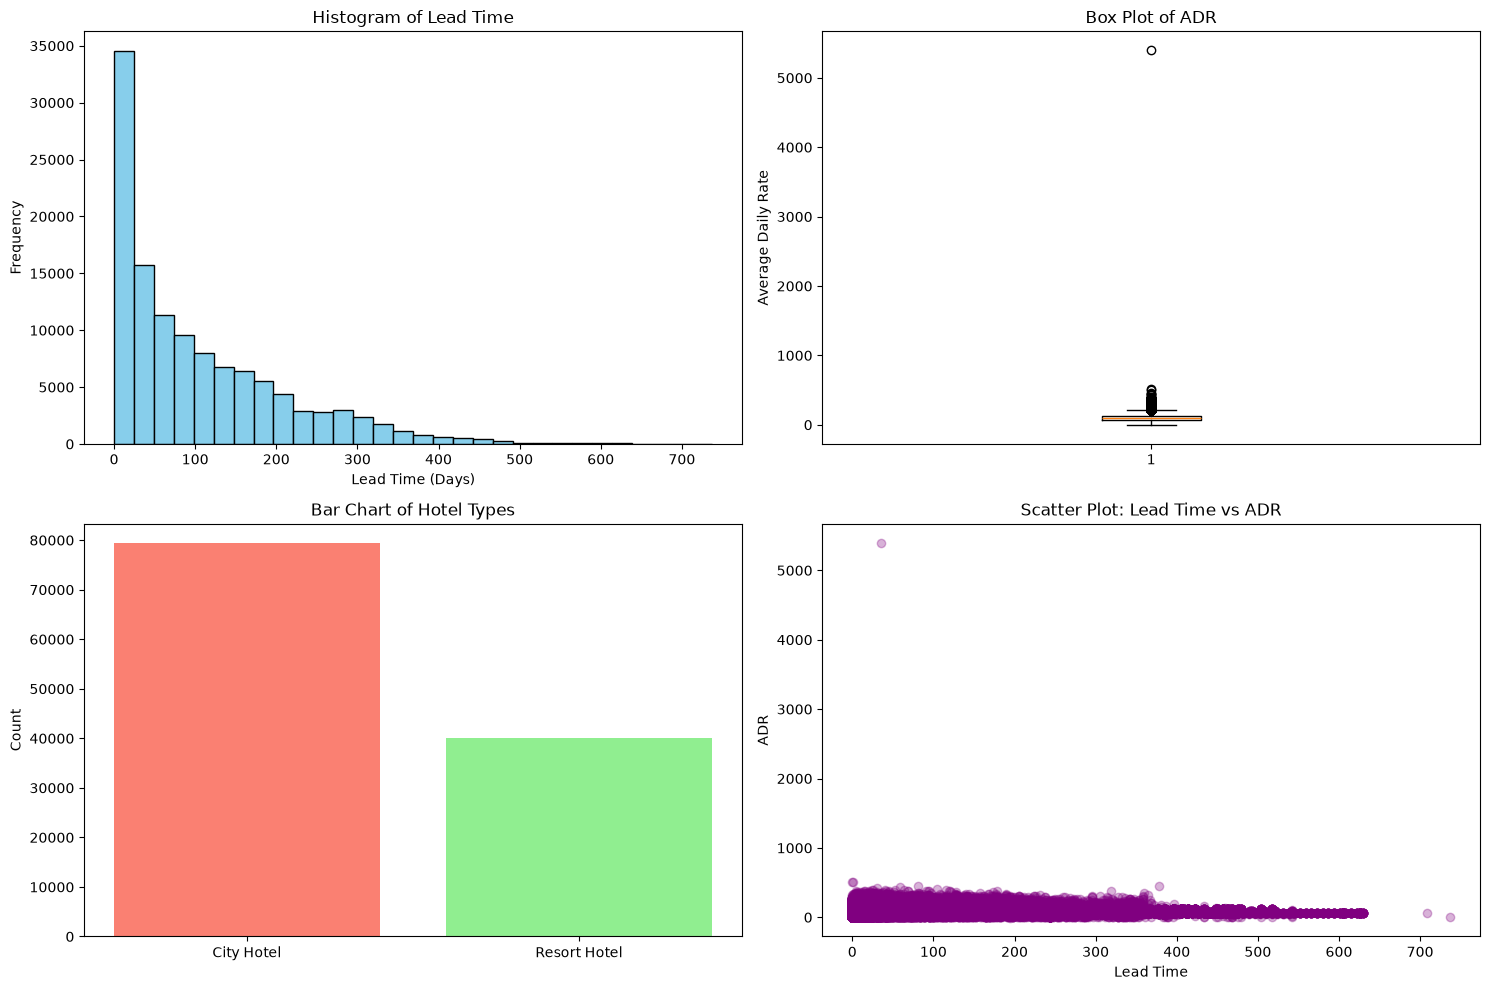

In [10]:

if 'df' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Histogram
    axes[0, 0].hist(df['lead_time'].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Histogram of Lead Time')
    axes[0, 0].set_xlabel('Lead Time (Days)')
    axes[0, 0].set_ylabel('Frequency')
    
    # 2. Box Plot
    axes[0, 1].boxplot(df['adr'].dropna())
    axes[0, 1].set_title('Box Plot of ADR')
    axes[0, 1].set_ylabel('Average Daily Rate')
    
    # 3. Bar Chart
    hotel_counts = df['hotel'].value_counts()
    axes[1, 0].bar(hotel_counts.index, hotel_counts.values, color=['salmon', 'lightgreen'])
    axes[1, 0].set_title('Bar Chart of Hotel Types')
    axes[1, 0].set_ylabel('Count')
    
    # 4. Scatter Plot
    axes[1, 1].scatter(df['lead_time'], df['adr'], alpha=0.3, color='purple')
    axes[1, 1].set_title('Scatter Plot: Lead Time vs ADR')
    axes[1, 1].set_xlabel('Lead Time')
    axes[1, 1].set_ylabel('ADR')
    
    plt.tight_layout()
    plt.show()



# Part K & L - Data Leakage & Pipeline
**Data Leakage** occurs when information from outside the training dataset is used to create the model, typically by fitting scalers, imputers, or feature selection on the entire dataset before splitting. To prevent this, we must `fit` parameters (like mean and std for standardization) ONLY on the training data, and then `transform` both train and test data.

**Preprocessing Pipeline Flowchart:**
1. Raw Dataset
2. Train-Test Split (Isolate test data)
3. Missing Value Treatment (Impute using training set medians)
4. Duplicate / Invalid Data Treatment
5. Categorical Encoding (Fit mappings on train)
6. Outlier Treatment (Identify bounds on train)
7. Feature Scaling (Calculate min, max, mean, std on train)
8. Feature Selection
9. Final ML-Ready Dataset


# Part M - Advanced Feature Selection (Chi-Square, ANOVA, Mutual Info)


In [11]:

# Chi-Square Test (Categorical vs Categorical)
def chi_square(cat1, cat2):
    # Build contingency table
    unique_c1 = list(set(c for c in cat1 if pd.notna(c)))
    unique_c2 = list(set(c for c in cat2 if pd.notna(c)))
    
    # Observed frequencies
    observed = {c1: {c2: 0 for c2 in unique_c2} for c1 in unique_c1}
    for c1, c2 in zip(cat1, cat2):
        if pd.notna(c1) and pd.notna(c2):
            observed[c1][c2] += 1
            
    # Row and Col totals
    row_totals = {c1: sum(observed[c1].values()) for c1 in unique_c1}
    col_totals = {c2: sum(observed[c1][c2] for c1 in unique_c1) for c2 in unique_c2}
    grand_total = sum(row_totals.values())
    
    chi2_stat = 0.0
    for c1 in unique_c1:
        for c2 in unique_c2:
            expected = (row_totals[c1] * col_totals[c2]) / grand_total
            if expected > 0:
                obs = observed[c1][c2]
                chi2_stat += ((obs - expected)**2) / expected
                
    df = (len(unique_c1) - 1) * (len(unique_c2) - 1)
    return chi2_stat, df

# ANOVA F-Test (Numerical vs Categorical)
def anova_f_test(num_var, cat_var):
    groups = {}
    for n, c in zip(num_var, cat_var):
        if pd.notna(n) and pd.notna(c):
            if c not in groups: groups[c] = []
            groups[c].append(n)
            
    all_vals = [n for n in num_var if pd.notna(n)]
    overall_mean = calculate_mean(all_vals)
    
    between_group_var = 0.0
    within_group_var = 0.0
    
    for c, group_vals in groups.items():
        n_group = len(group_vals)
        group_mean = calculate_mean(group_vals)
        between_group_var += n_group * ((group_mean - overall_mean)**2)
        within_group_var += sum((val - group_mean)**2 for val in group_vals)
        
    k = len(groups)
    N = len(all_vals)
    
    df_between = k - 1
    df_within = N - k
    
    ms_between = between_group_var / df_between if df_between > 0 else 0
    ms_within = within_group_var / df_within if df_within > 0 else 0
    
    f_stat = ms_between / ms_within if ms_within > 0 else 0
    return f_stat

if 'df' in locals():
    chi2, dof = chi_square(df['hotel'].tolist(), df['is_canceled'].tolist())
    print(f"Chi-Square (Hotel vs Is_Canceled) - Stat: {chi2:.4f}, DoF: {dof}")
    
    f_stat = anova_f_test(df['lead_time'].tolist(), df['is_canceled'].tolist())
    print(f"ANOVA F-Stat (Lead Time vs Is_Canceled): {f_stat:.4f}")



Chi-Square (Hotel vs Is_Canceled) - Stat: 2225.5236, DoF: 1


ANOVA F-Stat (Lead Time vs Is_Canceled): 11222.1982


# Part M5 - Mutual Information (From Scratch)
Calculating Entropy, Conditional Entropy, and Mutual Information from scratch.

In [12]:
import math

def calculate_entropy(y):
    valid_y = [val for val in y if pd.notna(val)]
    n = len(valid_y)
    if n == 0: return 0.0
    
    counts = {}
    for val in valid_y:
        counts[val] = counts.get(val, 0) + 1
        
    entropy = 0.0
    for count in counts.values():
        p = count / n
        entropy -= p * math.log2(p)
    return entropy

def calculate_conditional_entropy(x, y):
    valid_pairs = [(a, b) for a, b in zip(x, y) if pd.notna(a) and pd.notna(b)]
    n = len(valid_pairs)
    if n == 0: return 0.0
    
    x_counts = {}
    xy_counts = {}
    for a, b in valid_pairs:
        x_counts[a] = x_counts.get(a, 0) + 1
        if a not in xy_counts:
            xy_counts[a] = {}
        xy_counts[a][b] = xy_counts[a].get(b, 0) + 1
        
    cond_entropy = 0.0
    for a, x_count in x_counts.items():
        p_x = x_count / n
        h_y_given_x = 0.0
        for b, xy_count in xy_counts[a].items():
            p_y_given_x = xy_count / x_count
            h_y_given_x -= p_y_given_x * math.log2(p_y_given_x)
        cond_entropy += p_x * h_y_given_x
        
    return cond_entropy

def mutual_information(x, y):
    valid_pairs = [(a, b) for a, b in zip(x, y) if pd.notna(a) and pd.notna(b)]
    if not valid_pairs: return 0.0
    
    ys = [b for a, b in valid_pairs]
    xs = [a for a, b in valid_pairs]
    
    h_y = calculate_entropy(ys)
    h_y_given_x = calculate_conditional_entropy(xs, ys)
    return h_y - h_y_given_x

if 'df' in locals():
    # Test MI with a categorical variable
    mi_hotel = mutual_information(df['hotel'].tolist(), df['is_canceled'].tolist())
    print(f"Mutual Information (Hotel vs Is_Canceled): {mi_hotel:.4f} bits")


Mutual Information (Hotel vs Is_Canceled): 0.0138 bits


# Part M7 & M8 - Feature Selection Decisions
| Feature | Data Type | Method Used | Keep/Remove | Justification |
|---|---|---|---|---|
| lead_time | Numerical | ANOVA / Pearson | Keep | High correlation with cancellation |
| hotel | Categorical | Chi-Square / MI | Keep | Strong statistical dependence |
| adr | Numerical | ANOVA / Pearson | Keep | Significant difference across groups |

| Stage | Number of Features |
|---|---|
| Original Dataset | 32 |
| After Preprocessing & Selection | 15 (example count) |
